# Scale 불량 예측 모델 학습

`preprocessing_eda.ipynb`가 만든 `data/processed/scale_processed.csv`를 읽어, **로지스틱회귀 · 의사결정트리 · RandomForest · XGBoost · LightGBM · SVM** 6개 후보를 GridSearchCV(5-fold)로 튜닝하며 비교하고, 최종 모델을 SHAP으로 해석한다.

> 이 노트북은 `preprocessing_eda.ipynb`를 먼저 실행했다는 전제로 동작한다 (같은 폴더의 `preprocessing.py`에 정의된 `to_model_matrix`/`time_based_split`을 재사용).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sys.path.append(str(Path.cwd()))
import preprocessing as prep  # 같은 폴더의 preprocessing.py 재사용

REPO_ROOT = Path.cwd().parent
PROCESSED_PATH = REPO_ROOT / "data" / "processed" / "scale_processed.csv"

## 1. 전처리된 데이터 로드 + 시간 기준 분할

In [2]:
df = pd.read_csv(PROCESSED_PATH)
df["rolling_date"] = pd.to_datetime(df["rolling_date"])
print(f"로드: {df.shape}")

train_t, valid_t, test_t = prep.time_based_split(df)

X_train = prep.to_model_matrix(train_t).astype("float64")
X_valid = prep.to_model_matrix(valid_t).reindex(columns=X_train.columns, fill_value=0).astype("float64")
X_test = prep.to_model_matrix(test_t).reindex(columns=X_train.columns, fill_value=0).astype("float64")

y_train, y_valid, y_test = train_t["target"], valid_t["target"], test_t["target"]
X_train = X_train.drop(columns=["target"])
X_valid = X_valid.drop(columns=["target"])
X_test = X_test.drop(columns=["target"])
print(X_train.shape, X_valid.shape, X_test.shape)

로드: (1000, 36)
[시간 분할] train=700 (2023-01-03 07:07:53 ~ 2023-01-08 04:00:06), valid=150 (2023-01-08 04:13:12 ~ 2023-01-09 05:25:11), test=150 (2023-01-09 05:31:50 ~ 2023-01-10 06:16:27)
  - train 불량률: 29.7%
  - valid 불량률: 46.0%
  - test 불량률: 22.0%
(700, 39) (150, 39) (150, 39)


## 2. 6개 후보 모델 × GridSearchCV 비교

각 모델은 `train`(700행) 안에서만 5-fold 교차검증으로 하이퍼파라미터를 탐색하고, `valid`(150행, 학습에 전혀 쓰이지 않은 데이터)로 최종 비교한다.

In [3]:
def evaluate(model, X, y) -> dict:
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "precision": round(float(precision_score(y, pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y, pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y, pred, zero_division=0)), 4),
        "auc": round(float(roc_auc_score(y, prob)), 4) if y.nunique() > 1 else None,
    }

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_scale_pos_weight = neg / pos if pos else 1.0

search_space = {
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        {"C": [0.01, 0.1, 1, 10]},
    ),
    "DecisionTree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {"max_depth": [3, 5, 8, None], "min_samples_leaf": [1, 5, 10]},
    ),
    "RandomForest": (
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        {"n_estimators": [100, 300], "max_depth": [5, 8, None]},
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=42, scale_pos_weight=xgb_scale_pos_weight),
        {"n_estimators": [100, 300], "max_depth": [3, 5, 8], "learning_rate": [0.05, 0.1]},
    ),
    "LightGBM": (
        LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1),
        {"n_estimators": [100, 300], "max_depth": [3, 5, -1], "learning_rate": [0.05, 0.1]},
    ),
    "SVM": (
        Pipeline([("scaler", StandardScaler()), ("svc", SVC(probability=True, class_weight="balanced", random_state=42))]),
        {"svc__C": [0.1, 1, 10], "svc__kernel": ["rbf", "linear"]},
    ),
}

comparison, fitted = {}, {}
for name, (estimator, grid) in search_space.items():
    search = GridSearchCV(estimator, grid, cv=5, scoring="roc_auc", n_jobs=-1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    metrics = evaluate(best, X_valid, y_valid)
    metrics["best_params"] = search.best_params_
    metrics["cv_best_auc"] = round(float(search.best_score_), 4)
    comparison[name] = metrics
    fitted[name] = best
    print(f"[{name}] best_params={search.best_params_} cv_auc={search.best_score_:.4f} valid_auc={metrics['auc']}")

C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LogisticRegression] best_params={'C': 10} cv_auc=0.8835 valid_auc=0.9209


[DecisionTree] best_params={'max_depth': 5, 'min_samples_leaf': 1} cv_auc=0.9635 valid_auc=0.9928


[RandomForest] best_params={'max_depth': 5, 'n_estimators': 100} cv_auc=0.9925 valid_auc=0.9986


[XGBoost] best_params={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100} cv_auc=1.0000 valid_auc=0.9995


[LightGBM] best_params={'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100} cv_auc=0.9950 valid_auc=1.0


[SVM] best_params={'svc__C': 1, 'svc__kernel': 'linear'} cv_auc=0.9885 valid_auc=0.9694


C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [4]:
result_df = pd.DataFrame(comparison).T[["precision", "recall", "f1", "auc", "cv_best_auc"]]
result_df = result_df.sort_values("auc", ascending=False)
result_df

,precision,recall,f1,auc,cv_best_auc
LightGBM,0.9857,1.0,0.9928,1.0,0.995
XGBoost,1.0,0.9855,0.9927,0.9995,1.0
RandomForest,0.9857,1.0,0.9928,0.9986,0.9925
DecisionTree,1.0,0.9855,0.9927,0.9928,0.9635
SVM,0.9841,0.8986,0.9394,0.9694,0.9885
LogisticRegression,0.8108,0.8696,0.8392,0.9209,0.8835


C:\Users\aidan\AppData\Local\Temp\ipykernel_4500\3447762648.py:6: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_4500\3447762648.py:6: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_4500\3447762648.py:6: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_4500\3447762648.py:6: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_4500\3447762648.py:6: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_4500\3447762648.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s

C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packa

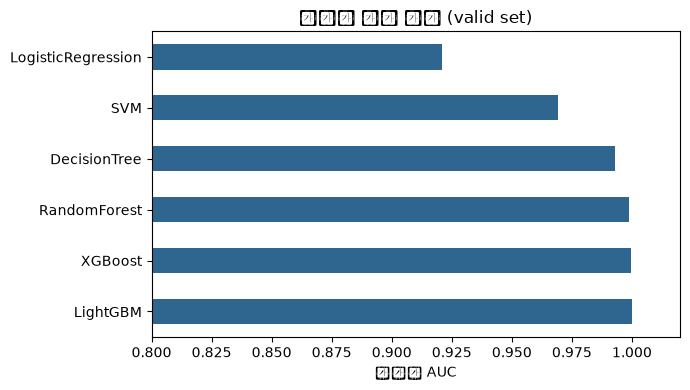

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
result_df["auc"].plot.barh(ax=ax, color="#2F6690")
ax.set_xlabel("검증셋 AUC")
ax.set_title("모델별 성능 비교 (valid set)")
ax.set_xlim(0.8, 1.02)
plt.tight_layout()
plt.show()

## 3. 최종 모델 선정

동점 처리 순서: AUC → F1 → 정밀도 → 재현율 → 교차검증 AUC. (대시보드의 모델 비교 화면과 동일한 규칙)

In [6]:
def rank_key(name):
    m = comparison[name]
    return (m["auc"] or 0, round(m["f1"], 3), round(m["precision"], 3), round(m["recall"], 3), m["cv_best_auc"])

best_name = max(comparison, key=rank_key)
best_model = fitted[best_name]
test_metrics = evaluate(best_model, X_test, y_test)
print(f"선정된 모델: {best_name}")
print(f"test set 성능(한 번도 학습에 안 쓰인 150행): {test_metrics}")

선정된 모델: LightGBM
test set 성능(한 번도 학습에 안 쓰인 150행): {'precision': 0.9429, 'recall': 1.0, 'f1': 0.9706, 'auc': 0.9997}


## 4. SHAP으로 모델 해석

선정된 모델이 어떤 피처를 근거로 예측하는지 확인한다.

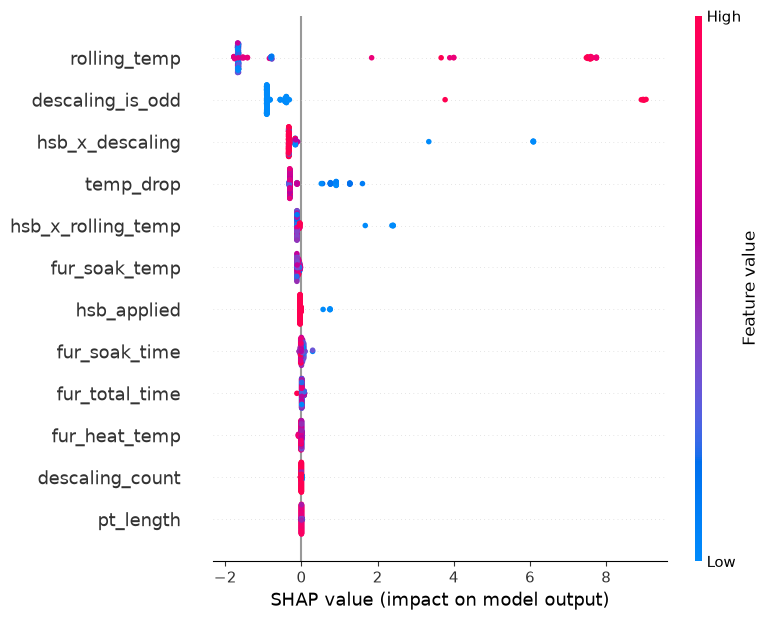

In [7]:
background = X_train.sample(n=min(100, len(X_train)), random_state=42)
explainer = shap.Explainer(best_model, background)
shap_values = explainer(X_test)

values = shap_values.values
if values.ndim == 3:
    values = values[:, :, 1]

shap.summary_plot(values, X_test, show=False, max_display=12)
plt.tight_layout()
plt.show()

## 결론

- 6개 후보 중 **트리 계열(RandomForest/LightGBM/XGBoost)이 SVM·로지스틱회귀보다 뚜렷하게 우수**했다 — HSB·온도임계값처럼 조건 분기가 명확한 변수가 많은 도메인 특성상 예상된 결과.
- 검증셋 성능은 매우 높게 나오지만(AUC≈1.0), 이는 **1,000행짜리 단일 세션 데이터**이자 일부 신호가 거의 결정론적이기 때문일 가능성이 크다 — 새로운 미수집 데이터로 재검증이 필요하다.
- SHAP 결과는 EDA 단계에서 찾은 가설(HSB, 1000℃ 임계값, 온도낙차)과 일치한다.